In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("06-study_hours_grades.csv")

In [3]:
df.head()

,study_hours,grade
0,3.745401,30.203939
1,9.507143,57.878452
2,7.319939,46.368401
3,5.986585,39.330717
4,1.560186,14.843888


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


In [5]:
df.describe()

,study_hours,grade
count,50.000000,50.000000
mean,4.459239,32.290305
std,2.888832,14.431931
min,0.205845,11.032281
25%,1.837670,21.062901
50%,4.360488,31.231858
75%,6.498549,41.683170
max,9.699099,60.573564


In [6]:
df["study_hours"].values

array([3.74540119, 9.50714306, 7.31993942, 5.98658484, 1.5601864 ,
       1.5599452 , 0.58083612, 8.66176146, 6.01115012, 7.08072578,
       0.20584494, 9.69909852, 8.32442641, 2.12339111, 1.81824967,
       1.8340451 , 3.04242243, 5.24756432, 4.31945019, 2.9122914 ,
       6.11852895, 1.39493861, 2.92144649, 3.66361843, 4.56069984,
       7.85175961, 1.99673782, 5.14234438, 5.92414569, 0.46450413,
       6.07544852, 1.70524124, 0.65051593, 9.48885537, 9.65632033,
       8.08397348, 3.04613769, 0.97672114, 6.84233027, 4.40152494,
       1.22038235, 4.9517691 , 0.34388521, 9.09320402, 2.58779982,
       6.62522284, 3.11711076, 5.20068021, 5.46710279, 1.84854456])

In [7]:
type(df["study_hours"].values)

numpy.ndarray

In [8]:
torch.tensor(df["study_hours"].values)

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015, 1.2204, 4.9518, 0.3439, 9.0932, 2.5878,
        6.6252, 3.1171, 5.2007, 5.4671, 1.8485], dtype=torch.float64)

In [9]:
df.corr()

,study_hours,grade
study_hours,1.000000,0.991902
grade,0.991902,1.000000


In [10]:
y = torch.tensor(df["grade"].values)
X = torch.tensor(df["study_hours"].values)

In [11]:
X

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015, 1.2204, 4.9518, 0.3439, 9.0932, 2.5878,
        6.6252, 3.1171, 5.2007, 5.4671, 1.8485], dtype=torch.float64)

In [12]:
y

tensor([30.2039, 57.8785, 46.3684, 39.3307, 14.8439, 16.3600, 11.9829, 55.4231,
        40.7430, 41.8775, 11.6774, 57.7253, 50.2683, 21.8403, 21.1532, 21.0328,
        23.5337, 35.6194, 32.2598, 26.5125, 39.6343, 16.6034, 22.3946, 25.9257,
        34.4286, 51.9713, 19.8397, 37.7188, 40.3440, 11.0323, 41.1000, 21.6023,
        13.1809, 60.5736, 53.0421, 52.0637, 25.4048, 14.2856, 44.3952, 28.0325,
        15.6626, 35.4731, 14.6752, 54.4295, 21.3220, 42.1226, 27.4164, 36.6609,
        36.2760, 20.2693], dtype=torch.float64)

In [13]:
# train - test split

In [14]:
train_split=int(len(X)*0.8)
X_train,y_train=X[:train_split],y[:train_split]
X_test,y_test =X[train_split:],y[train_split:]

In [15]:
X_test

tensor([1.2204, 4.9518, 0.3439, 9.0932, 2.5878, 6.6252, 3.1171, 5.2007, 5.4671,
        1.8485], dtype=torch.float64)

In [16]:
X_train

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015], dtype=torch.float64)

In [17]:
y_train

tensor([30.2039, 57.8785, 46.3684, 39.3307, 14.8439, 16.3600, 11.9829, 55.4231,
        40.7430, 41.8775, 11.6774, 57.7253, 50.2683, 21.8403, 21.1532, 21.0328,
        23.5337, 35.6194, 32.2598, 26.5125, 39.6343, 16.6034, 22.3946, 25.9257,
        34.4286, 51.9713, 19.8397, 37.7188, 40.3440, 11.0323, 41.1000, 21.6023,
        13.1809, 60.5736, 53.0421, 52.0637, 25.4048, 14.2856, 44.3952, 28.0325],
       dtype=torch.float64)

In [18]:
y_test

tensor([15.6626, 35.4731, 14.6752, 54.4295, 21.3220, 42.1226, 27.4164, 36.6609,
        36.2760, 20.2693], dtype=torch.float64)

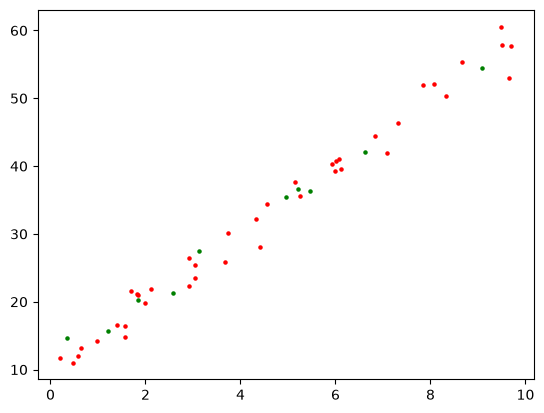

In [19]:
plt.scatter(X_train,y_train,c="r",s=5,label="Training Data")
plt.scatter(X_test,y_test,c="g",s=5,label="Test Data")
plt.show()

In [20]:
# pytorch ann

In [21]:
from torch import nn

In [22]:
class SimpleLinearRegressionModel(nn.Module): # tüm PyTorch modülleri nn.Module sınıfından türetilir
    def __init__(self):
        super().__init__() # üst sınıfın yani nn.Module' nin yapıcı metodunu çağırır

        # modelin öğrenilebilir parametrelerini oluşturuyoruz
        # eğitim sırasında optimizer bu değerleri günceller
        self.weights = nn.Parameter(torch.randn(1,dtype=torch.float),requires_grad=True)
        self.bias = nn.Parameter(torch.randn(1,dtype=torch.float),requires_grad=True)
        
    # ileri besleme (forward pass)
    # modelin tahmin denklemi : y = ax + b
    def forward(self,x:torch.Tensor)->torch.Tensor:
        return self.weights * x + self.bias

In [23]:
# optimizer (optimazyon algoritması) = modelin ağırlıklarını güncelleyen algoritmadır.
# Amacı : modelin yaptığı hatayı ( loss ) mümkün olduğunca azlatmaktır.

In [24]:
torch.manual_seed(42)

model_0 = SimpleLinearRegressionModel()
#model_0 = torch.compile(model_0)

In [25]:
# torch.compile() = işlemleri analiz edip mümkün olduğunca tek seferde veya daha verimli şekilde çalıştırmaya çalışır.

In [26]:
list(model_0.parameters()) # modeldeki öğrenilebilir parametreleri döndürür.

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [27]:
model_0.state_dict() # modelin tüm durumunu sözlük şeklinde döndürür

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [28]:
with torch.inference_mode():
    y_pred = model_0(X_test)

In [29]:
len(X_test)

10

In [30]:
len(y_pred)

10

In [31]:
len(y_test)

10

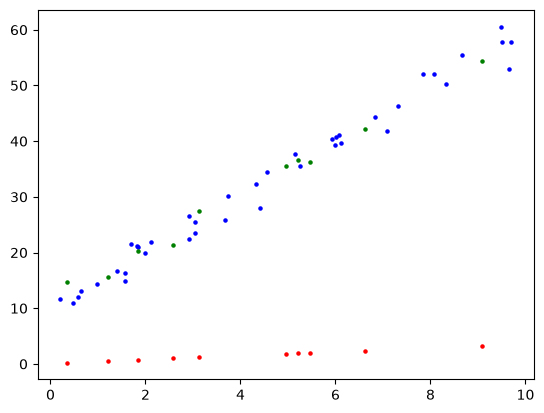

In [32]:
plt.scatter(X_train,y_train,c="b",s=5,label="Training Data")
plt.scatter(X_test,y_test,c="g",s=5,label="Test Data")
plt.scatter(X_test,y_pred,c="r",s=5,label="Pred Data")
plt.show()

In [33]:
loss_fn = nn.MSELoss()
# loss_fn = nn.L1Loss() -> MAE

optimizer = torch.optim.SGD(params = model_0.parameters(),lr = 0.001)

In [34]:
torch.manual_seed(42)

epochs = 100

# grafik çizmek için değerleri saklıyoruz
train_loss_values = []
test_loss_values = []
epoch_count = []

# eğitim döngüsü başlıyor
for epoch in range(epochs):
    #train mode
    model_0.train()
    # model eğitim verisini kullanarak tahmin yapıyor
    y_pred = model_0(X_train)

    # tahmin edilen değerlerle gerçek değerleri karşılaştırıyoruz
    loss = loss_fn(y_pred, y_train)

    # eski gradyanları temizler
    optimizer.zero_grad()
    # gradyanları hesaplar -> backpropagation denir
    loss.backward()
    # parametreleri günceller
    optimizer.step()

    # test mode
    model_0.eval()

    # gradient hesaplamasını kapatır -> sadece tahmin yapar öğrenme yapmaz
    with torch.inference_mode():
        # test verisinde tahmin yapar
        test_pred = model_0(X_test)
        # test kaybını hesaplar
        test_loss = loss_fn(test_pred, y_test) # loss_fn(test_pred, y_test.type(torch.float))

        # her 5 epoch'ta bir kayıt alır
        if epoch % 5 == 0:
            # epoch numarasını kaydeder
            epoch_count.append(epoch)
            # eğitim loss'unu kaydeder
            train_loss_values.append(loss.detach().numpy()) # detach -> loss tensor'ını hesaplama grafiğinden ayırır
            # test loss'unu kaydeder
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch}, Train Loss: {loss}, Test Loss: {test_loss}")

Epoch: 0, Train Loss: 1156.0767463081781, Test Loss: 858.3088765088272
Epoch: 5, Train Loss: 633.9334744710083, Test Loss: 484.2837829868178
Epoch: 10, Train Loss: 352.99125276114285, Test Loss: 280.90521005460033
Epoch: 15, Train Loss: 201.80191856738534, Test Loss: 169.8918797355706
Epoch: 20, Train Loss: 120.41268871324436, Test Loss: 108.98031233032034
Epoch: 25, Train Loss: 76.57232180621143, Test Loss: 75.32370882849361
Epoch: 30, Train Loss: 52.931428428694815, Test Loss: 56.55033419714631
Epoch: 35, Train Loss: 40.157054153236494, Test Loss: 45.9453113422317
Epoch: 40, Train Loss: 33.22852214719357, Test Loss: 39.85290344471839
Epoch: 45, Train Loss: 29.44508410079029, Test Loss: 36.274774134597365
Epoch: 50, Train Loss: 27.353844189863754, Test Loss: 34.11265188608324
Epoch: 55, Train Loss: 26.173217192098285, Test Loss: 32.75872353470674
Epoch: 60, Train Loss: 25.482772613444595, Test Loss: 31.87363984152036
Epoch: 65, Train Loss: 25.05632900940991, Test Loss: 31.265739395147

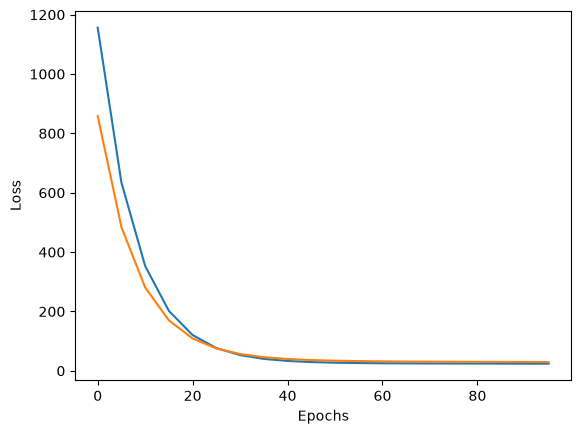

In [35]:
plt.plot(epoch_count, train_loss_values, label= "Train Loss")
plt.plot(epoch_count, test_loss_values, label= "Test Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.show()

In [36]:
model_0.state_dict()

OrderedDict([('weights', tensor([6.3044])), ('bias', tensor([1.5651]))])

In [37]:
model_0.eval()
with torch.inference_mode():
    y_preds = model_0(X_test)

In [38]:
X_test

tensor([1.2204, 4.9518, 0.3439, 9.0932, 2.5878, 6.6252, 3.1171, 5.2007, 5.4671,
        1.8485], dtype=torch.float64)

In [39]:
y_preds

tensor([ 9.2589, 32.7829,  3.7331, 58.8921, 17.8796, 43.3330, 21.2166, 34.3522,
        36.0318, 13.2191], dtype=torch.float64)

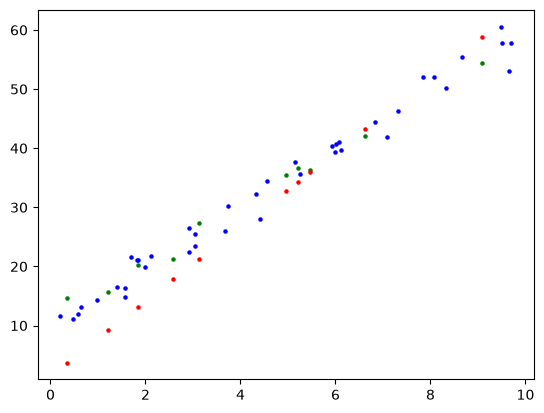

In [40]:
plt.scatter(X_train,y_train,c="b",s=5,label="Training Data")
plt.scatter(X_test,y_test,c="g",s=5,label="Test Data")
plt.scatter(X_test,y_preds,c="r",s=5,label="Predictions Data")
plt.show()